In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_score
)

from sklearn.preprocessing import label_binarize


In [2]:
df = pd.read_csv("dataset_limpio.csv")
df.head()

,pt,eta,phi,charge,pos_x,pos_y,pos_z,particle_type,event_id
0,2.400150,0.739663,1.62212,1.0,0.000647,0.000633,0.039879,electron,22109111
1,1.314830,0.945947,-3.09573,1.0,0.000698,0.000623,-0.029173,track,22109111
2,1.384250,-1.488470,-2.93427,1.0,0.000703,0.000611,-0.029091,track,22109111
3,0.973126,0.576321,-2.91378,1.0,0.000704,0.000611,-0.020457,track,22109111
4,1.697150,1.373240,-2.92621,1.0,0.000701,0.000623,-0.020329,track,22109111


In [3]:
# Variables predictoras y objetivo
X = df[["pt", "eta", "phi", "charge", "pos_x", "pos_y", "pos_z"]]
y = df["particle_type"]

# Codificación de etiquetas
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
classes = encoder.classes_

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

# Escalado (para consistencia)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
%%time
# Definir hiperparámetros
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy"
)

grid.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros obtenidos:")
print(grid.best_params_)

# Modelo final entrenado solo una vez
model_dt = grid.best_estimator_


Mejores hiperparámetros obtenidos:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
CPU times: user 1.41 s, sys: 276 ms, total: 1.68 s
Wall time: 46.1 s


=== Reporte de clasificación ===
              precision    recall  f1-score   support

    electron       0.00      0.00      0.00        37
        muon       0.00      0.00      0.00        99
      photon       1.00      1.00      1.00        63
       track       0.98      1.00      0.99      7528

    accuracy                           0.98      7727
   macro avg       0.50      0.50      0.50      7727
weighted avg       0.97      0.98      0.97      7727



/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


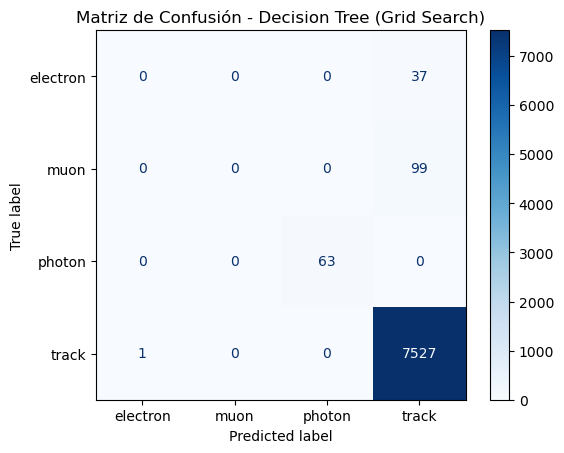

In [6]:
y_pred_dt = model_dt.predict(X_test_scaled)

print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred_dt, target_names=classes))

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión - Decision Tree (Grid Search)")
plt.show()

/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


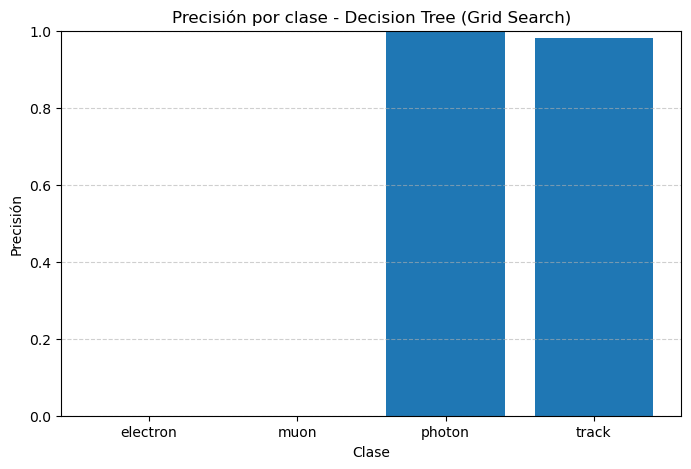

In [7]:
precisiones_dt = precision_score(y_test, y_pred_dt, average=None)

plt.figure(figsize=(8,5))
plt.bar(classes, precisiones_dt)
plt.ylabel("Precisión")
plt.xlabel("Clase")
plt.title("Precisión por clase - Decision Tree (Grid Search)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


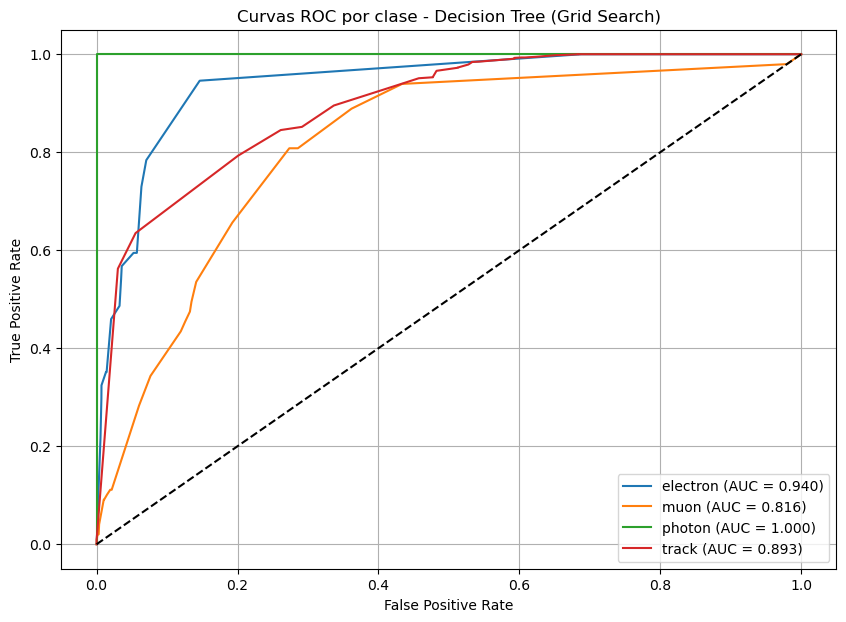

In [8]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

y_scores_dt = model_dt.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 7))

for i, clase in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores_dt[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clase} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC por clase - Decision Tree (Grid Search)")
plt.legend()
plt.grid(True)
plt.show()


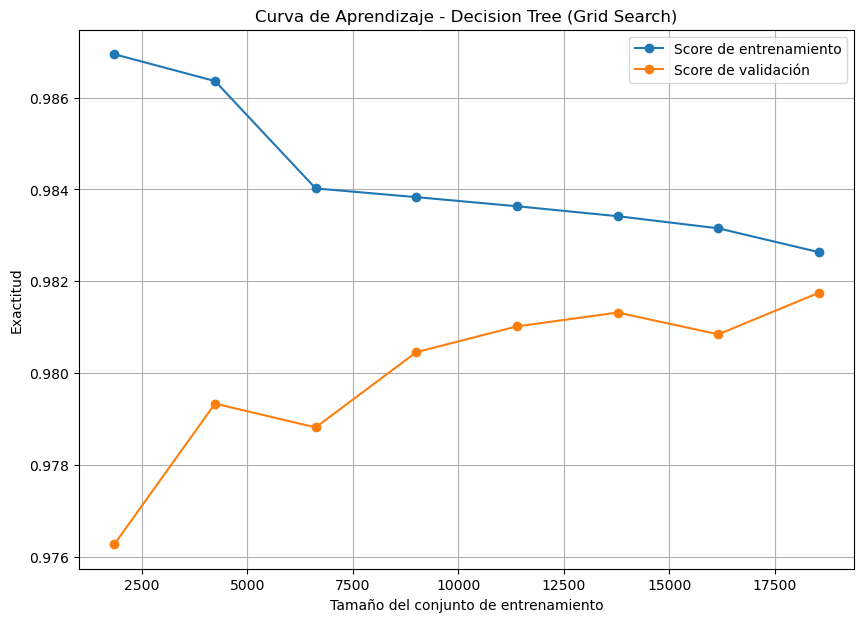

In [9]:
train_sizes, train_scores, test_scores = learning_curve(
    DecisionTreeClassifier(**grid.best_params_, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_mean, marker="o", label="Score de entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Score de validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de Aprendizaje - Decision Tree (Grid Search)")
plt.legend()
plt.grid(True)
plt.show()


## SIN TRACKS

In [10]:
df = pd.read_csv("dataset_limpio_notracks.csv")
df.head()

,pt,eta,phi,charge,pos_x,pos_y,pos_z,particle_type,event_id
0,2.400150,0.739663,1.622120,1.0,0.000647,0.000633,0.039879,electron,22109111
1,0.838852,-1.914380,2.947160,-1.0,0.000671,0.000501,-0.012415,muon,22109111
2,2.646500,-2.273300,0.817141,1.0,0.000773,0.000570,0.002240,muon,22109111
3,1.736600,-2.463090,-1.792570,1.0,0.002726,0.000183,-0.001184,muon,22109111
4,35.556000,0.005784,1.834000,0.0,0.000726,0.000609,-0.047592,photon,652620608


In [11]:
# Variables predictoras y objetivo
X = df[["pt", "eta", "phi", "charge", "pos_x", "pos_y", "pos_z"]]
y = df["particle_type"]

# Codificación de etiquetas
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
classes = encoder.classes_

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

# Escalado (para consistencia)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
%%time
# Definir hiperparámetros
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy"
)

grid.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros obtenidos:")
print(grid.best_params_)

# Modelo final entrenado solo una vez
model_dt = grid.best_estimator_


Mejores hiperparámetros obtenidos:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
CPU times: user 481 ms, sys: 163 ms, total: 644 ms
Wall time: 5.27 s


=== Reporte de clasificación ===
              precision    recall  f1-score   support

    electron       0.48      0.41      0.44        37
        muon       0.79      0.84      0.81        99
      photon       1.00      1.00      1.00        63

    accuracy                           0.81       199
   macro avg       0.76      0.75      0.75       199
weighted avg       0.80      0.81      0.80       199



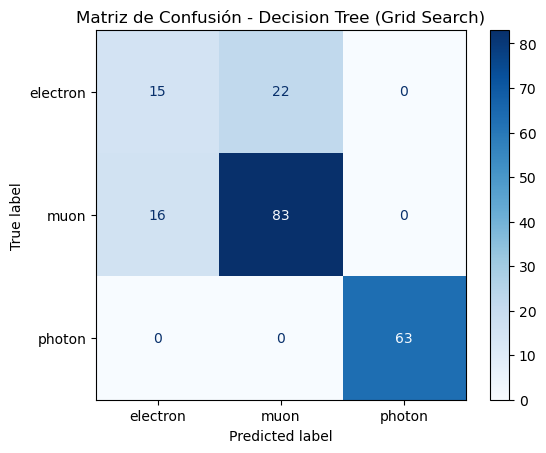

In [13]:
y_pred_dt = model_dt.predict(X_test_scaled)

print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred_dt, target_names=classes))

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión - Decision Tree (Grid Search)")
plt.show()

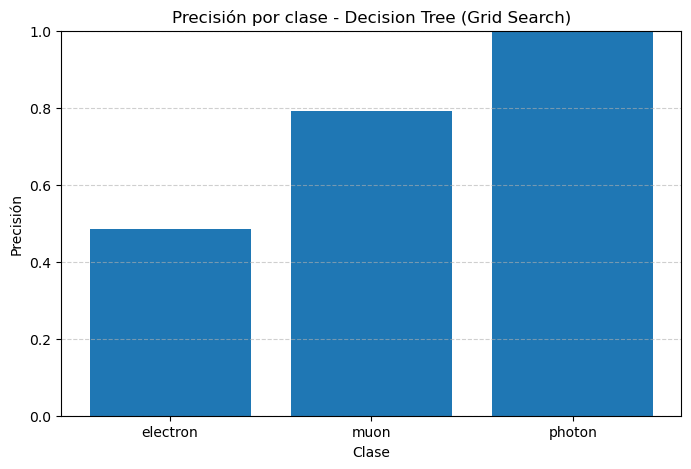

In [14]:
precisiones_dt = precision_score(y_test, y_pred_dt, average=None)

plt.figure(figsize=(8,5))
plt.bar(classes, precisiones_dt)
plt.ylabel("Precisión")
plt.xlabel("Clase")
plt.title("Precisión por clase - Decision Tree (Grid Search)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


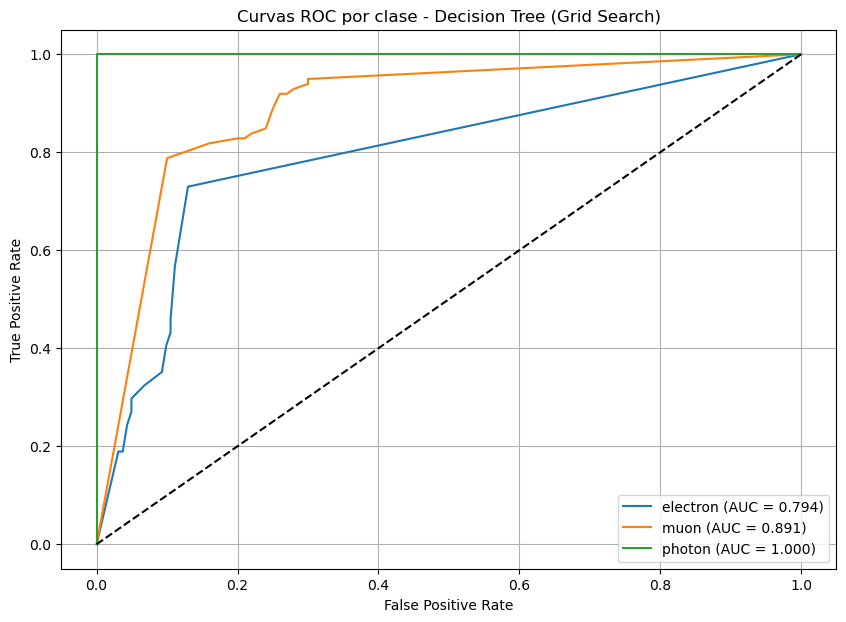

In [15]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

y_scores_dt = model_dt.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 7))

for i, clase in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores_dt[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clase} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC por clase - Decision Tree (Grid Search)")
plt.legend()
plt.grid(True)
plt.show()


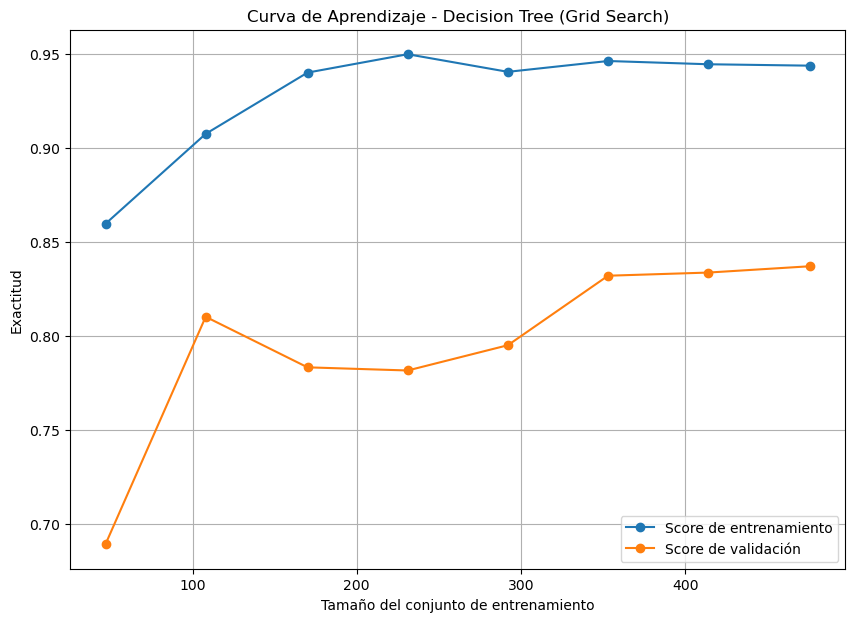

In [16]:
train_sizes, train_scores, test_scores = learning_curve(
    DecisionTreeClassifier(**grid.best_params_, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_mean, marker="o", label="Score de entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Score de validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de Aprendizaje - Decision Tree (Grid Search)")
plt.legend()
plt.grid(True)
plt.show()
